# Traffic Accident Risk Prediction 

In [2]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Load dataset

In [3]:
df = pd.read_csv(r"C:\Users\Admin\Downloads\traffic_accident_risk.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)


Dataset loaded successfully
Shape: (5010, 24)


# EDA

In [4]:
# df.info()

In [5]:
# df.duplicated().sum()
# df.drop_duplicates(inplace=True)

In [6]:
# CLEAN COLUMN NAMES
df.columns = (df.columns.str.strip().str.lower().str.replace(" ", "_"))
print("\nDataset columns:")
print(df.columns.tolist())



Dataset columns:
['accident_id', 'age', 'driver_experience', 'vehicle_speed', 'traffic_density', 'visibility', 'number_of_vehicles', 'road_width', 'historical_accidents', 'rainfall', 'temperature', 'hour', 'day_of_week', 'weather', 'road_condition', 'road_type', 'junction_type', 'lighting', 'traffic_control', 'area_type', 'vehicle_type', 'driver_distraction', 'alcohol_involved', 'accident_risk']


In [7]:
# REMOVE ACCIDENT ID

df = df.drop(columns=["accident_id"],errors="ignore")

# Feature Selection

In [8]:
# DEFINE TARGET
TARGET = "accident_risk"
if TARGET not in df.columns:

    raise ValueError(
        f"\nTarget column '{TARGET}' not found.\n"
        f"Available columns:\n{df.columns.tolist()}"
    )


In [9]:
 # DEFINE CATEGORICAL COLUMNS
categorical_columns = ["weather","driver_distraction","driver_experience","alcohol_involved","road_condition","junction_type",
                       "traffic_control","vehicle_type","lighting", "area_type", "day_of_week", "road_type"]

In [10]:
 # DEFINE NUMERICAL COLUMNS
numerical_columns = ["historical_accidents", "road_width","number_of_vehicles","age","vehicle_speed","hour","rainfall","temperature",
                     "visibility","traffic_density"]


In [11]:
 # CHECK REQUIRED COLUMNS

required_columns = (
    categorical_columns +
    numerical_columns +
    [TARGET]
)

missing_columns = [
    col
    for col in required_columns
    if col not in df.columns
]
if missing_columns:

    raise ValueError(
        "\nThe following columns are missing from your CSV:\n"
        + str(missing_columns)
        + "\n\nAvailable columns:\n"
        + str(df.columns.tolist())
    )


In [12]:
# KEEP ONLY REQUIRED COLUMNS
df = df[required_columns].copy()


In [13]:
# FORCE CATEGORICAL COLUMNS TO STRING
for col in categorical_columns:
        df[col] = (
        df[col]
        .fillna("Unknown")
        .astype(str)
        .str.strip()
    )

In [14]:
# FORCE NUMERICAL COLUMNS TO NUMERIC
for col in numerical_columns:
        df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

In [15]:
# REMOVE INFINITE VALUES
df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

# Visualizations

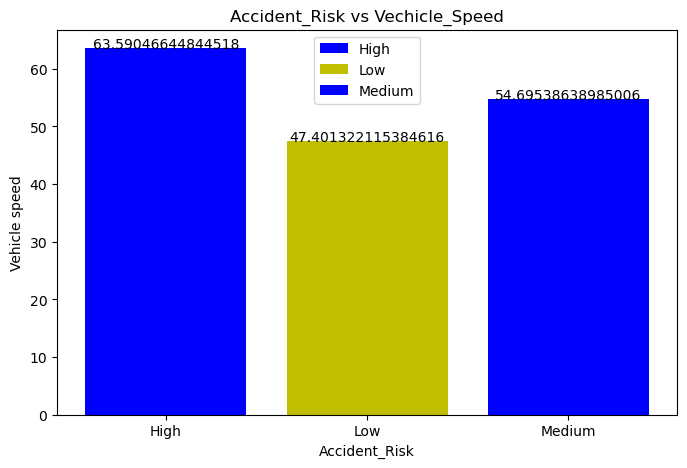

In [16]:
x=df.groupby("accident_risk")["vehicle_speed"].mean()
# x
plt.figure(figsize=(8, 5))
plt.bar(x.index,x.values,color=["b","y"],label=x.index)
for i,v in enumerate(x.values):
    plt.text(i,v,f"{v:0}",ha="center")
plt.ylabel("Vehicle speed")
plt.xlabel("Accident_Risk")
plt.title("Accident_Risk vs Vechicle_Speed")
plt.legend()
plt.show()

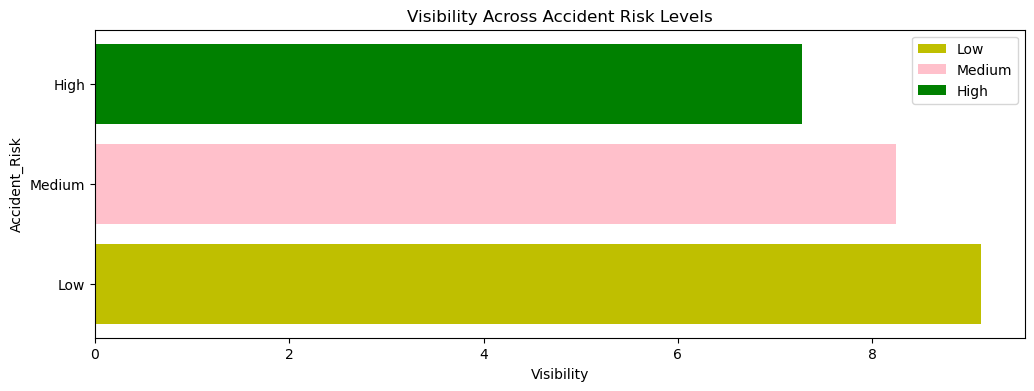

In [17]:
a=df.groupby("accident_risk")["visibility"].mean().sort_values(ascending=False)
plt.figure(figsize=(12,4))
plt.barh(a.index,a.values,color=["y","pink","g"],label=a.index)
plt.ylabel("Accident_Risk")
plt.xlabel("Visibility")
plt.title("Visibility Across Accident Risk Levels")
plt.legend()

plt.show()


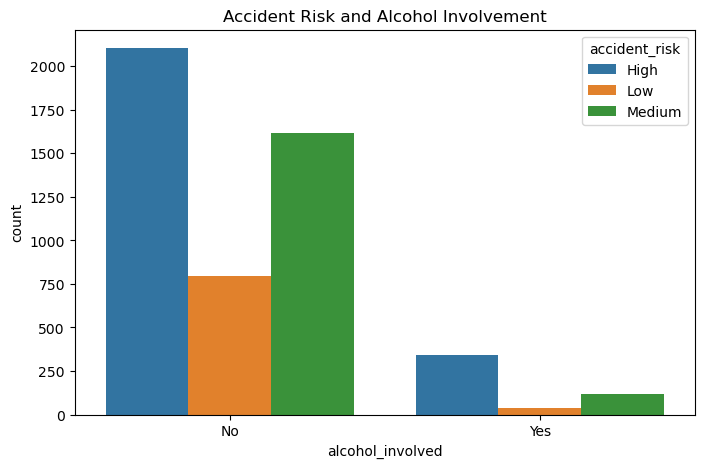

In [18]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df,x="alcohol_involved",hue="accident_risk")
plt.title("Accident Risk and Alcohol Involvement")
plt.show()

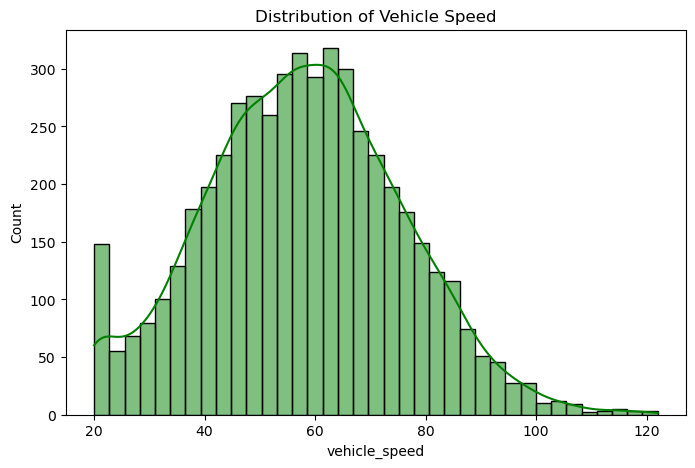

In [19]:
# VEHICLE SPEED ANALYSIS:
plt.figure(figsize=(8, 5))
sns.histplot(data=df,x="vehicle_speed",kde=True,color="g")
plt.title("Distribution of Vehicle Speed")
plt.show()

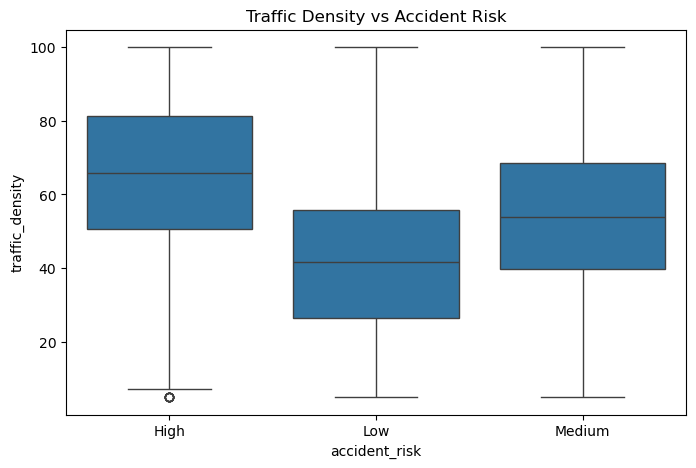

In [20]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df,x="accident_risk",y="traffic_density")
plt.title("Traffic Density vs Accident Risk")

plt.show()

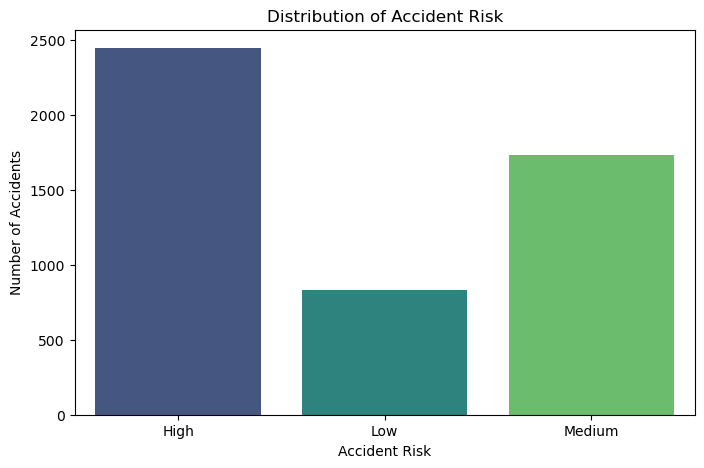

In [21]:
plt.figure(figsize=(8, 5))
sns.countplot( data=df,x="accident_risk",palette="viridis")

plt.title("Distribution of Accident Risk")
plt.xlabel("Accident Risk")
plt.ylabel("Number of Accidents")

plt.show()

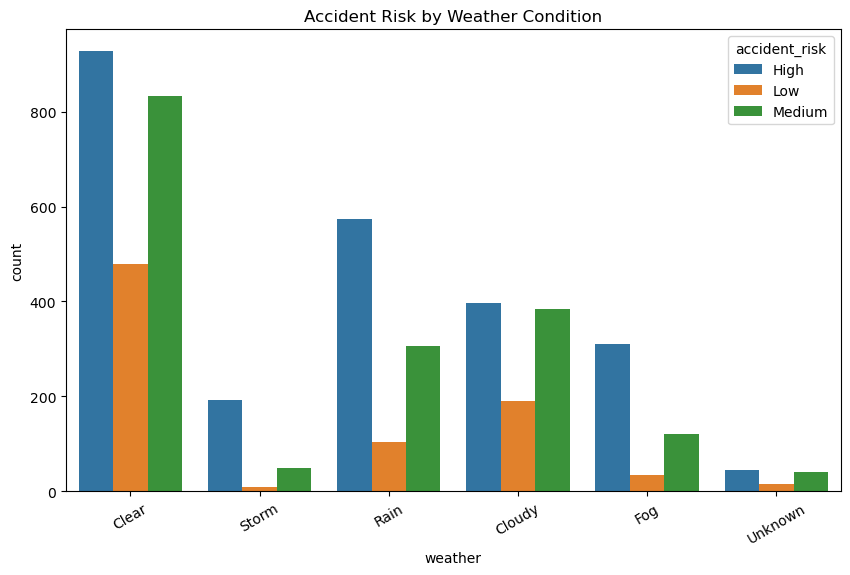

In [22]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df,x="weather",hue="accident_risk")
plt.title("Accident Risk by Weather Condition")
plt.xticks(rotation=30)
plt.show()

In [23]:
X = df.drop( columns=[TARGET])
y = df[TARGET]


In [24]:
# CLEAN TARGET
y = y.astype(str).str.strip()
print("\nTarget values:")
print(y.value_counts())



Target values:
accident_risk
High      2444
Medium    1734
Low        832
Name: count, dtype: int64


In [25]:
# print("\nCategorical columns:")
# print(categorical_columns)

# print("\nNumerical columns:")
# print(numerical_columns)


# TRAIN TEST SPLIT

In [26]:
# TRAIN TEST SPLIT
from sklearn. model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [27]:
X_train.head(2)

,weather,driver_distraction,driver_experience,alcohol_involved,road_condition,junction_type,traffic_control,vehicle_type,lighting,area_type,...,historical_accidents,road_width,number_of_vehicles,age,vehicle_speed,hour,rainfall,temperature,visibility,traffic_density
1338,Clear,Yes,34,No,Dry,Roundabout,Stop Sign,Car,Daylight,Urban,...,9,9.3,4,53,73.3,19,0.05,27.4,7.07,NaN
3979,Clear,No,20,No,Dry,Crossroad,Signal,Truck,Daylight,Suburban,...,6,7.1,5,35,52.8,19,0.40,29.7,5.74,98.1


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (OneHotEncoder,StandardScaler)

from sklearn.impute import (SimpleImputer)

In [29]:
# NUMERIC AND CATEGORICAL PIPELINE
numeric_pipeline = Pipeline([ ("imputer",SimpleImputer( strategy="median")), ( "scaler", StandardScaler() )])
categorical_pipeline = Pipeline([("imputer",SimpleImputer(strategy="most_frequent")), ("encoder",OneHotEncoder( handle_unknown="ignore") )])

In [30]:
from sklearn.compose import ColumnTransformer
 # COLUMN TRANSFORMER
preprocessor = ColumnTransformer(transformers=[ ("numeric",numeric_pipeline,numerical_columns),
               ("categorical",categorical_pipeline,categorical_columns)],remainder="drop")

#MACHINE LEARNING MODELS 


In [31]:
from sklearn.linear_model import LogisticRegression



In [47]:
models = {

    "Logistic Regression": LogisticRegression(
        max_iter=2000
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        max_depth=10
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        max_depth=15
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [45]:
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000))
])

# Train
logistic_model.fit(X_train, y_train)

# Train and Test Score
train_score_logistic = logistic_model.score(X_train,y_train)


print(train_score_logistic)

0.7325349301397206


In [46]:
test_score_logistic = logistic_model.score(X_test, y_test)
print(test_score_logistic)

0.6996007984031936


In [42]:
from sklearn.tree import DecisionTreeClassifier
decision_tree_model = Pipeline([("preprocessor", preprocessor),("classifier", DecisionTreeClassifier( max_depth=10, random_state=42 ))])
# Train
decision_tree_model.fit( X_train, y_train)
# Train and Test Score
train_score_dt = decision_tree_model.score(X_train,y_train)

print(train_score_dt)

0.8338323353293413


In [48]:
test_score_dt = decision_tree_model.score(X_test,y_test)
print(test_score_dt)

0.5389221556886228


In [49]:
from sklearn.ensemble import RandomForestClassifier
random_forest_model = Pipeline([("preprocessor", preprocessor),("classifier", RandomForestClassifier(
                      n_estimators=200, max_depth=15, random_state=42,n_jobs=-1))])

random_forest_model.fit(X_train,y_train)

# Train and Test Score
train_score_rf = random_forest_model.score(X_train,y_train)
print("Train_score_rf",train_score_rf)


Train_score_rf 0.9987524950099801


In [50]:
test_score_rf = random_forest_model.score(X_test,y_test)
print("Test_scor_rf",test_score_rf)

Test_scor_rf 0.6427145708582834


In [51]:
from sklearn.ensemble import GradientBoostingClassifier
gradient_boosting_model = Pipeline([("preprocessor", preprocessor),("classifier", GradientBoostingClassifier(
                          n_estimators=200,learning_rate=0.05, max_depth=3,random_state=42 ))])

# Train
gradient_boosting_model.fit(X_train,y_train)

# Train and Test Score
train_score_gb = gradient_boosting_model.score( X_train,y_train)


print("Train Score:", train_score_gb)




Train Score: 0.8006487025948104


In [52]:
test_score_gb = gradient_boosting_model.score( X_test,y_test)
print("Test Score:", test_score_gb)

Test Score: 0.655688622754491


# PREDICTION OF RANDOMEFOREST MODEL

In [53]:
# prediction of RandomForest model
y_pred = random_forest_model.predict(X_test)

In [54]:
from sklearn.metrics import classification_report

In [55]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

        High       0.69      0.90      0.79       489
         Low       0.76      0.23      0.36       166
      Medium       0.52      0.47      0.49       347

    accuracy                           0.64      1002
   macro avg       0.66      0.54      0.55      1002
weighted avg       0.65      0.64      0.61      1002



In [56]:
from sklearn.metrics import confusion_matrix

In [57]:
cm=confusion_matrix(y_test,y_pred)

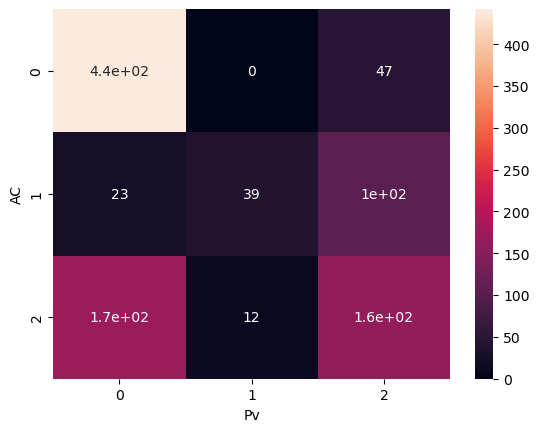

In [58]:
sns.heatmap(cm,annot=True)
plt.ylabel("AC")
plt.xlabel("Pv")
plt.show()

# Saving and Loading Model

In [59]:
import pickle

In [60]:

with open("Traffic_accidentrisk_model.pkl","wb") as f:
    pickle.dump(random_forest_model,f)

In [1]:
x= df.groupby("acciden_risk")["visibility"].mean()

NameError: name 'df' is not defined